# EVASPA zones

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import ListedColormap
from rasterio.features import geometry_mask

In [3]:
if os.environ["EVASPA_TEST_DATA_PATH"] is None:
    msg = "Variable EVASPA_TEST_DATA_PATH must be set"
    raise ValueError(msg)
if os.environ["MNT_PATH"] is None:
    os.environ["MNT_PATH"] = os.environ["EVASPA_TEST_DATA_PATH"]

In [4]:
from evaspa import trishna, zones
from evaspa.dem import get_dem_from_tiles

### Data

In [5]:
land = trishna.get_land_mask()

### Define valid pixels in a tile

In [6]:
def plot_valid_pixels(
    tile_ids: list[str],
    land: gpd.GeoDataFrame,
    slope_threshold: float = 30,
    range_threshold: int = 300,
    simplify: bool = True,
) -> None:
    """
    Plot valid pixels
    """
    # Read DEM
    dem = get_dem_from_tiles(tile_ids)
    # Compute valid pixels
    pvalid, dem = zones.define_valid_pixels(
        dem,
        land,
        slope_threshold=slope_threshold,
        range_threshold=range_threshold,
        simplify=simplify,
    )
    # Plot
    valid = dem["valid"]
    ax = plt.gca()
    fig = plt.gcf()
    valid_cmap = ListedColormap([(1.0, 0.0, 0.0, 1.0), (0.0, 0.0, 0.0, 0.0)])
    dem["height"].plot(
        ax=ax, vmin=dem["height"].min(), vmax=dem["height"].max()
    )
    valid.plot(ax=ax, cmap=valid_cmap, add_colorbar=False)
    plt.title(
        f"{'/'.join(tile_ids)} - Slope < {slope_threshold} - Range = {range_threshold} { ' - cleaning ' if simplify else ''}\n Percentage of valid pixels = {pvalid:.2f}"
    )
    fig.savefig(
        f'valid_pixels_{"-".join(tile_ids)}_slope{slope_threshold}_range{range_threshold}{ "_simplified" if simplify else ""}.png'
    )
    plt.show()


def plot_valid_zones(
    tile_ids: list[str],
    land: gpd.GeoDataFrame,
    slope_threshold: float = 30,
    range_threshold: int = 300,
    simplify: bool = True,
    poly_simplify: int = 0,
) -> None:
    # Read DEM
    dem = get_dem_from_tiles(tile_ids)
    # Compute zones
    pvalid, nbvalid, polys = zones.define_valid_zones(
        tile_ids,
        land,
        slope_threshold=slope_threshold,
        range_threshold=range_threshold,
        simplify=simplify,
    )
    # Transform polygons to mask
    valid = xr.DataArray(
        geometry_mask(
            polys.geoms,
            out_shape=(dem.sizes["y"], dem.sizes["x"]),
            transform=dem.transform,
        ),
        coords=dem.coords,
        dims=("y", "x"),
    )
    valid.data = ~valid.data
    # Plot
    ax = plt.gca()
    fig = plt.gcf()
    valid_cmap = ListedColormap([(1.0, 0.0, 0.0, 1.0), (0.0, 0.0, 0.0, 0.0)])
    dem["height"].plot(
        ax=ax, vmin=dem["height"].min(), vmax=dem["height"].max()
    )
    valid.plot(ax=ax, cmap=valid_cmap, add_colorbar=False)
    plt.title(
        f"{'/'.join(tile_ids)} - Slope < {slope_threshold} - Range = {range_threshold} { ' - cleaning ' if simplify else ''}\n Percentage of valid pixels = {pvalid:.2f}"
    )
    fig.savefig(
        f'valid_zones_{"-".join(tile_ids)}_slope{slope_threshold}_range{range_threshold}{ "_simplified" if simplify else ""}{ "_polysimp" + str(poly_simplify) if poly_simplify is not None else ""}.png'
    )
    plt.show()

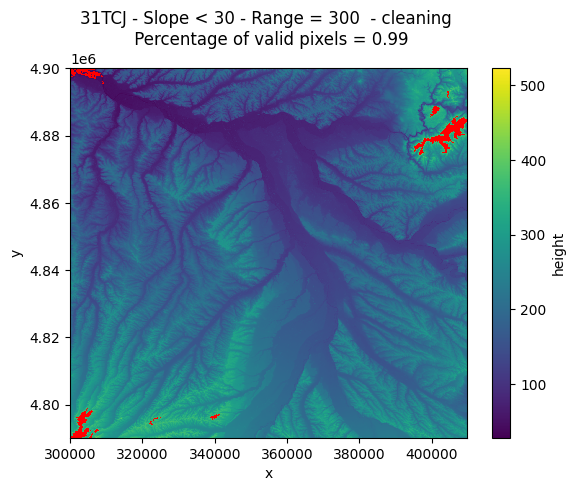

In [7]:
plot_valid_pixels(["31TCJ"], land, range_threshold=300)

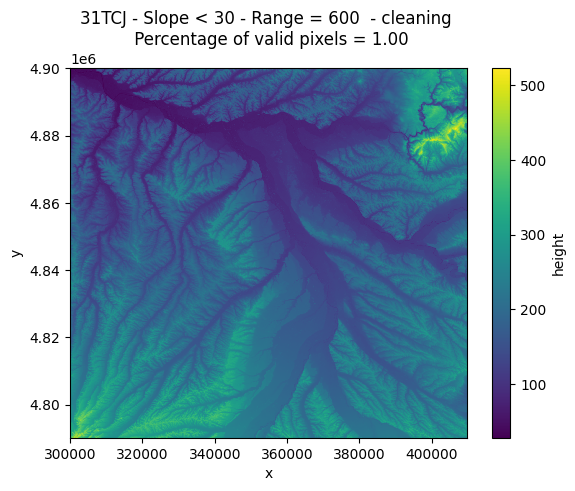

In [8]:
plot_valid_zones(
    ["31TCJ"], land, slope_threshold=30, range_threshold=600, poly_simplify=600
)